#### Começamos nosso projeto em virtude da importância do diagnóstico precoce como ferramenta no combate a doenças, em particular as de alta gravidade, como as do coração. Um diagnóstico precoce pode ser a difenrença entre a vida e a morte, e pra isso esse projeto foi desenvolvido: atuar no auxílio ao tratamento de doenças do coração

### Nossos dados consistem de uma base de dados extraída do Kaggle, mais específicamente, a base de Heart Disease, da competição finalizada ao fim de fevereiro (28/02/2026)

Como a base de dados não possui missings, e também não possui outliers significativos (ou seja, os dados extremos, que existem, são possíveis no mundo real) não foi feito nenhum tratamento de dados específico relativo a isso, pois o nosso modelo principal o CatboostClassifier, consegue lidar bem com essa problemática usando seus splits, ou seja, segmentando a relevância de cada variável e desprezando variações particularmente intensas. Por esse contexto, nossos feature enginering se restringiu a agrupar categorias raras que poderiam gerar ruído no nosso modelo, e considerar cada categoria corretamente, ou seja, eliminando a influência de variáveis "numéricas" que na verdade eram categóricas, já que se o modelo imputasse incorretamente o conceito de "distância" que não necessariamente existe pra tais categorias, poderiamos ter prejuízos ao modelo.

# O overview do nosso df é:

In [1]:
import pandas as pd

df=pd.read_csv('train.csv')
df.head(3)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence


Portanto, foram alteradas algumas variáveis para categorias, ou seja, sex, Chest pain type, exercise angina, ekg results, FBS over 120, Slope of ST e etc. Esse processo foi feito e salvo no .csv df_att.csv, que possui nosso df após todas essas atualizações. O mesmo encontra-se na pasta "deprecated data_results", junto com outros elementos como os folds usados na geração de OOF's.

# Quanto à correlação no df, podemos visualizar abaixo, e usaremos o df_att justamente para evitar problemas com isso.:

In [2]:
import joblib

df_att = joblib.load('df_att.pkl')

df_att.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   Age                      630000 non-null  int64   
 1   Sex                      630000 non-null  category
 2   Chest pain type          630000 non-null  category
 3   BP                       630000 non-null  int64   
 4   Cholesterol              630000 non-null  int64   
 5   FBS over 120             630000 non-null  category
 6   EKG results              630000 non-null  category
 7   Max HR                   630000 non-null  int64   
 8   Exercise angina          630000 non-null  category
 9   ST depression            630000 non-null  float64 
 10  Slope of ST              630000 non-null  category
 11  Number of vessels fluro  630000 non-null  int64   
 12  Thallium                 630000 non-null  int64   
 13  Heart Disease            630000 non-null  ob

## Como pode ser visto, o devido tratamento foi dado com relação às variáveis categóricas, e agora, para visualizar a correlação fazemos:

In [3]:
df_att.select_dtypes(include='number').corr()

,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Thallium
Age,1.000000,-0.003960,0.019485,-0.097542,0.103064,0.102758,0.150124
BP,-0.003960,1.000000,-0.004597,0.004391,-0.004024,-0.003143,-0.005884
Cholesterol,0.019485,-0.004597,1.000000,-0.048575,0.044678,0.048800,0.061817
Max HR,-0.097542,0.004391,-0.048575,1.000000,-0.229462,-0.236319,-0.306912
ST depression,0.103064,-0.004024,0.044678,-0.229462,1.000000,0.293642,0.316891
Number of vessels fluro,0.102758,-0.003143,0.048800,-0.236319,0.293642,1.000000,0.333460
Thallium,0.150124,-0.005884,0.061817,-0.306912,0.316891,0.333460,1.000000


Como nossa variável alvo tecnicamente é categórica, para visualizarmos a correlação com ela, fazemos:

In [4]:
df_att['Heart Disease'] = df_att['Heart Disease'].map({'Presence': 1, 'Absence': 0})

In [5]:
df_att.select_dtypes(include='number').corr()

,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Thallium,Heart Disease
Age,1.000000,-0.003960,0.019485,-0.097542,0.103064,0.102758,0.150124,0.212091
BP,-0.003960,1.000000,-0.004597,0.004391,-0.004024,-0.003143,-0.005884,-0.005181
Cholesterol,0.019485,-0.004597,1.000000,-0.048575,0.044678,0.048800,0.061817,0.082753
Max HR,-0.097542,0.004391,-0.048575,1.000000,-0.229462,-0.236319,-0.306912,-0.440985
ST depression,0.103064,-0.004024,0.044678,-0.229462,1.000000,0.293642,0.316891,0.430641
Number of vessels fluro,0.102758,-0.003143,0.048800,-0.236319,0.293642,1.000000,0.333460,0.438604
Thallium,0.150124,-0.005884,0.061817,-0.306912,0.316891,0.333460,1.000000,0.605776
Heart Disease,0.212091,-0.005181,0.082753,-0.440985,0.430641,0.438604,0.605776,1.000000


Vemos portanto, correlação forte entre a presença de Heart Disease e Thallium e correlação inversa com MAX HR. Vamos visualizar essa relação graficamente:

<Axes: xlabel='Thallium', ylabel='count'>

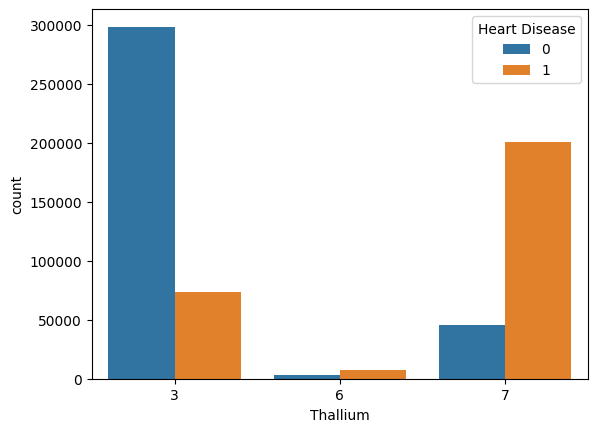

In [6]:
import seaborn as sns

sns.countplot(data=df_att, x='Thallium', hue='Heart Disease')

## Aqui podemos ver claramente uma fortíssima relação entre o Thallium 6 e 7 e nosso risco de doença cardíaca.

In [7]:
df['Heart Disease'] = df_att['Heart Disease']
gb = df.groupby('Thallium')['Heart Disease'].mean()

In [8]:
gb

Thallium
3    0.198049
6    0.686394
7    0.815391
Name: Heart Disease, dtype: float64

#### Um exemplo minimalissta de "modelo", seria apenas definirmos um corte através do Thalium, ou seja, Thallium 6 e 7 definirmos como possui doença cardíaca, e Thalium 3 definirmos como não possui. Isso, no entanto, nos daria um "modelo" reducionista e extremamente inefetivo. Assim endo, escolheremos um modelo que seja capaz de 'pesar' automaticamente os impactos de cada variável, e definir o quanto ela impacta na chance de a pessoa estar ou não com doença em seu coração.

Para isso, escolhemos o modelo CatBoost. após tunning pesado, obtemos os hiper-parametros a serem utilizados no modelo:



In [9]:
params = {'iterations': 1233, 'depth': 5, 'learning_rate': 0.5563228358640898,
          'l2_leaf_reg': 1.2388924496891942, 'border_count': 157}


Treinaremos o modelo abaixo:

In [10]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

df = df_att.copy()
target = 'Heart Disease'

X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8)

cat_features = X.select_dtypes(exclude='number').columns.tolist()

model = CatBoostClassifier(**params)
model.fit(X_train, y_train, cat_features=cat_features, verbose=200)


0:	learn: 0.3713199	total: 256ms	remaining: 5m 15s
200:	learn: 0.2517018	total: 19.8s	remaining: 1m 41s
400:	learn: 0.2390922	total: 39.6s	remaining: 1m 22s
600:	learn: 0.2291996	total: 59.6s	remaining: 1m 2s
800:	learn: 0.2202826	total: 1m 19s	remaining: 43s
1000:	learn: 0.2127035	total: 1m 40s	remaining: 23.2s
1200:	learn: 0.2055668	total: 2m	remaining: 3.21s
1232:	learn: 0.2044308	total: 2m 3s	remaining: 0us


CatBoostClassifier(border_count=157, depth=5, iterations=1233, l2_leaf_reg=1.2388924496891942, learning_rate=0.5563228358640898)

#### Para avaliar nosso modelo, usaremos o ROC_AUC score.

In [11]:
from sklearn.metrics import roc_auc_score
y_pred = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_pred)


0.9472481175951754

Conseguimos um roc_auc expressivo, digno de um excelente modelo. Como métrica extremamente efetiva de que o modelo não está overfittado, temos em uma base de dados que sequer pertence ao df, um roc_auc ainda melhor, que é o roc_auc da competição do Kaggle. Nosso modelo, na base de teste oficial (que não tem a variável default, e por isso não foi utilizada) obteve um ROC_AUC de 0.9594, ficando entre os top 25% melhores modelos do Kaggle. (1038/4317)

Apesar de serem tentadas incrementar outras variáveis, e rodar um stack, nenhum modelo desempenhou melhor que esse. Todo o storytelling do desenvolvimento do modelo encontra-se no READ_ME.md. O stacking foi bem feito, e o desempenho foi extremamente próximo do modelo principal (CatBoost), indicando que provavelmente, os outros modelos do stacking, apesar de muito bem avaliados, apenas geraram ruído, mesmo que as recomendações de diferenciação da natureza dos modelos tenha sido seguida. (Usamos MLPC, LogisticRegressor e Catboost como meta modelos para um LogisticRegressor.)

#### Destaca-se que, apesar de o gap entre o modelo treinado e o melhor modelo do Kaggle existir, ele encontra-se no nível de ruído estatístico, chegando ao nível de que os modelos apenas melhoram intencionalmente overfittando na "base de testes" ou seja, fazendo múltiplos lançamentos até encontrar o modelo que melhor "veste" a base de testes. Como fizemos poucas submissões, essa expectativa não era razoável. A título de comparação, o top 3 fez 109, 59 e 72 submissões respectivamente, enquanto da nossa parte foram feitas apenas 4. A diferença entre os dois modelos está na ordem da quarta casa decimal do roc_auc, representando um esforço "desnecessário" por um desempenho pouco relevante, especialmente levando em consideração o tempo de tunning - 10 horas.

A confusion Matrix do nosso modelo foi:

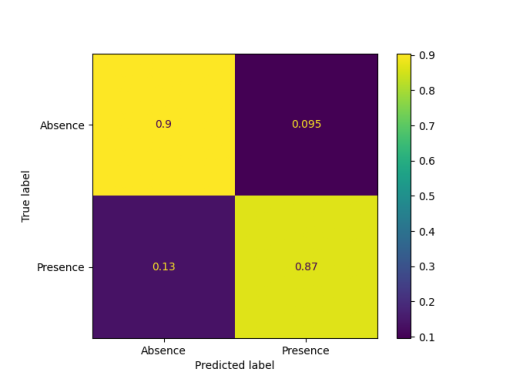

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("Confusion Matrix - First Model.png")
plt.imshow(img)
plt.axis("off")
plt.show()

Ao longo do projeto, diversos modelos foram montados, e tornados obsoletos, inclusive os mencionados como parte da composição dos stacking de modelos. Tais modelos estão organizados em:
Deprecated Models e deprecated data. Em deprecated data, também encontra-se o df_att.csv, que foi utilizado ao longo do projeto antes de ter seu uso transposto para o df_att.pkl. Essa mudança se deu pois o csv NÂO carrega as propriedades de tipo de coluna. OU seja, se atualmente nosso df possui colunas category quando carregado com o pickle, ao carregar usando o csv, essas colunas seriam object, e não category. Então, para questão de comodidade do processamento e padronização dos dados, além de questões de eficiencia de código com relação a categoria vs object, foi tornado padrão no projeto o uso do .pkl em detrimento do .csv.

O stacking final encontra-se em full_data_stack, onde também existem outros comentários sobre o stack realizado.

# Considerações finais:
- O desempenho do modelo foi extremamente significativo, estando em pé de igualdade com o top 1 do Kaggle, com a diferença estando a nível de ruído estatístico.
- O modelo possui uma ótima discriminação do default, e pouquíssimos erros dos tipos mais nocivos. 9% para o tipo de erro que é custoso em relação à confiabilidade do cliente (Afirmar que ele está doente, mas não está doente) e 13% no tipo de erro que é nocivo à segurança do cliente, que é quando se afirma que ele não está doente, e ele ESTÁ. A prioridade deve ser definida de acordo com as diretrizes do negócio. A minha principal recomendação é:
- Definir diversos threshold associados a diferentes decisões. OU seja, rodar threshold de alta confiabilidade (modelo previu 95%+ de risco do cliente estar doente) e criar campanhas de upselling, oferecendo ao cliente testes mais específicos pra detectar garantir e detectar QUAL a doença que ele possui, oferecendo descontos caso ele não possua doença nenhuma, como responsabilização pelo erro. Rodar um threshold menos criterioso, e informar o cliente da situação, do risco de erro do modelo, deixá-lo decidir se realiza ou não exames mais específicos. Outra ideia, que não teremos como implementar, pois necessitaria de dados que não temos, seria rodar um modelo decidir qual doença nosso cliente provavelmente tem, e assim, poder rodar outros testes complementares. Em casos de doenças mais graves, deixar o cliente a par de qual o problema dele, e como proceder daí em diante, tendo em vista que a gravidade e risco imediato de cada problema não são iguais.

PS; uma alternativa possível é criar um desconto que é proporcional à chance do cliente estar doente, ou seja, para clientes com 95% de chance, oferecemos um desconto de (95/2)% do valor em caso de erro. Isso, no entanto, é algo que só pode ser decidido em conjunto com os setores financeiros e margem de lucro da empresa, que é uma formação que devido a natureza dos dados (competição do Kaggle) não temos como obter.

PS.2: foi usado no modelo apresentado (a confusion matrix) o threshold padrão, 0.5. Não faz muito sentido alterar o Threshold sem ter conhecimento mais específico do negócio. Foi rodado anteriormente a busca por um threshold que maximizasse a ACURÁCIA, mas o uso foi descontinuado pois aumentou os erros de tipo mais nocivo ao modelo de negócio (falso negativo) que é o pior erro possível nesse tipo de contexto.